In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/kpi_raw.csv')

# Compute revenue per employee
df['revenue_per_employee_usd_k'] = (df['revenue_usd_b'] * 1_000_000) / df['employee_count']

# Style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

print(df[['chain', 'sales_per_sqft_usd', 'acsi_score_2026', 'revenue_per_employee_usd_k']])

         chain  sales_per_sqft_usd  acsi_score_2026  \
0      Walmart                 400               75   
1       Kroger                 550               76   
2   Albertsons                 580               76   
3       Costco                1300               81   
4  Trader Joes                1900               86   
5      Aldi US                 750               81   
6       Publix                 650               84   
7  Whole Foods                1000               81   
8        H-E-B                 800               83   

   revenue_per_employee_usd_k  
0                  324.285714  
1                  359.657702  
2                  282.105263  
3                 1162.100457  
4                  342.857143  
5                 1608.000000  
6                  229.615385  
7                  175.238095  
8                  287.500000  


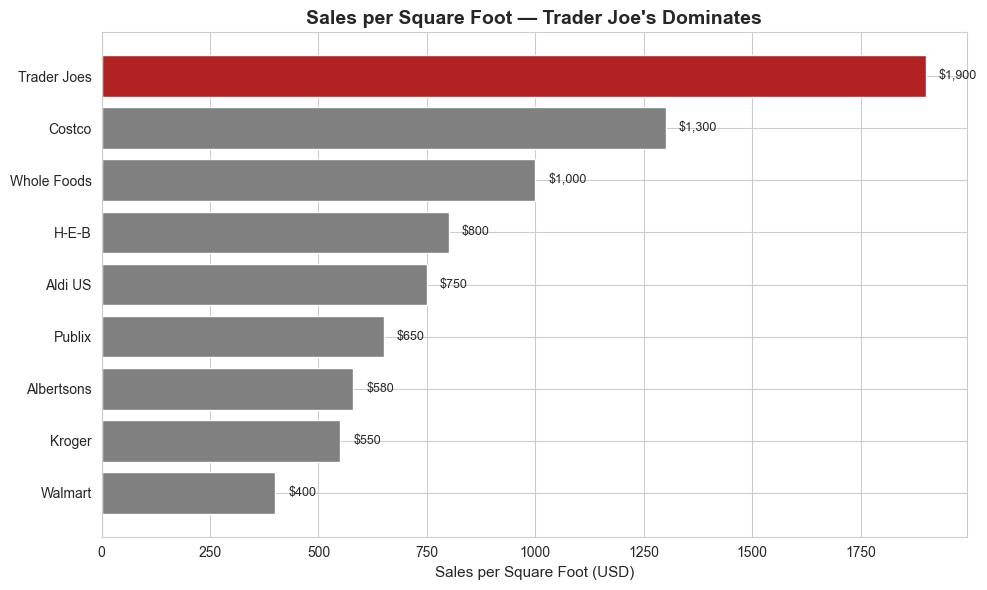

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
data = df.sort_values('sales_per_sqft_usd', ascending=True)

# TJ highlighted in red, others gray
colors = ['#B22222' if c == 'Trader Joes' else '#808080' for c in data['chain']]

bars = ax.barh(data['chain'], data['sales_per_sqft_usd'], color=colors)

ax.set_xlabel('Sales per Square Foot (USD)', fontsize=11)
ax.set_title("Sales per Square Foot — Trader Joe's Dominates", fontsize=14, fontweight='bold')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 30, bar.get_y() + bar.get_height()/2, 
            f'${width:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../output/chart1_grocery_rev_per_store.png', dpi=150, bbox_inches='tight')
plt.show()

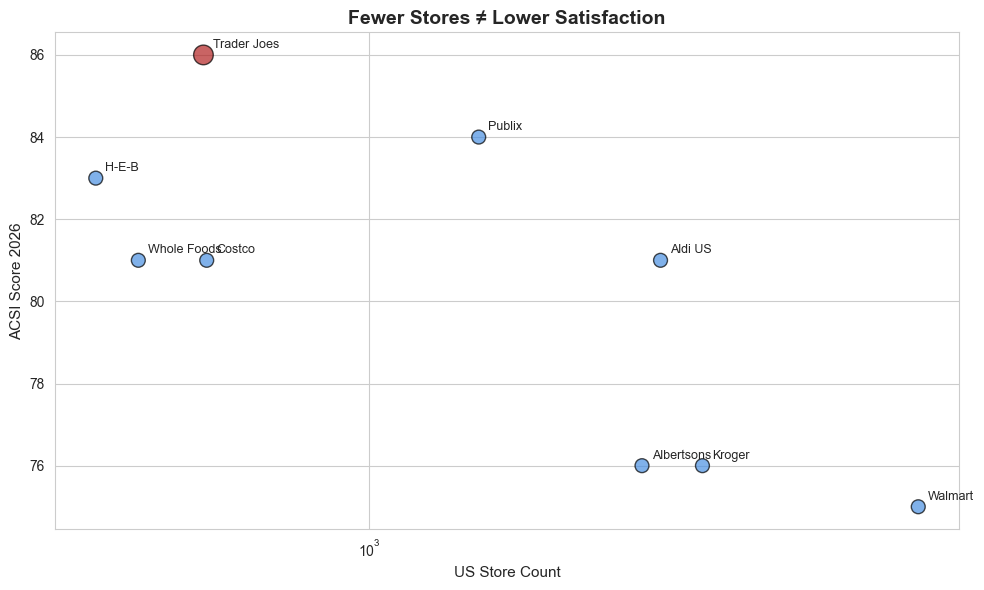

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#B22222' if c == 'Trader Joes' else '#4A90E2' for c in df['chain']]
sizes = [200 if c == 'Trader Joes' else 100 for c in df['chain']]

ax.scatter(df['store_count_us'], df['acsi_score_2026'], 
           c=colors, s=sizes, alpha=0.7, edgecolors='black')

for _, row in df.iterrows():
    ax.annotate(row['chain'], 
                (row['store_count_us'], row['acsi_score_2026']),
                xytext=(7, 5), textcoords='offset points', fontsize=9)

ax.set_xlabel('US Store Count', fontsize=11)
ax.set_ylabel('ACSI Score 2026', fontsize=11)
ax.set_title('Fewer Stores ≠ Lower Satisfaction', fontsize=14, fontweight='bold')
ax.set_xscale('log')

plt.tight_layout()
plt.savefig('../output/chart2_stores_vs_acsi.png', dpi=150, bbox_inches='tight')
plt.show()

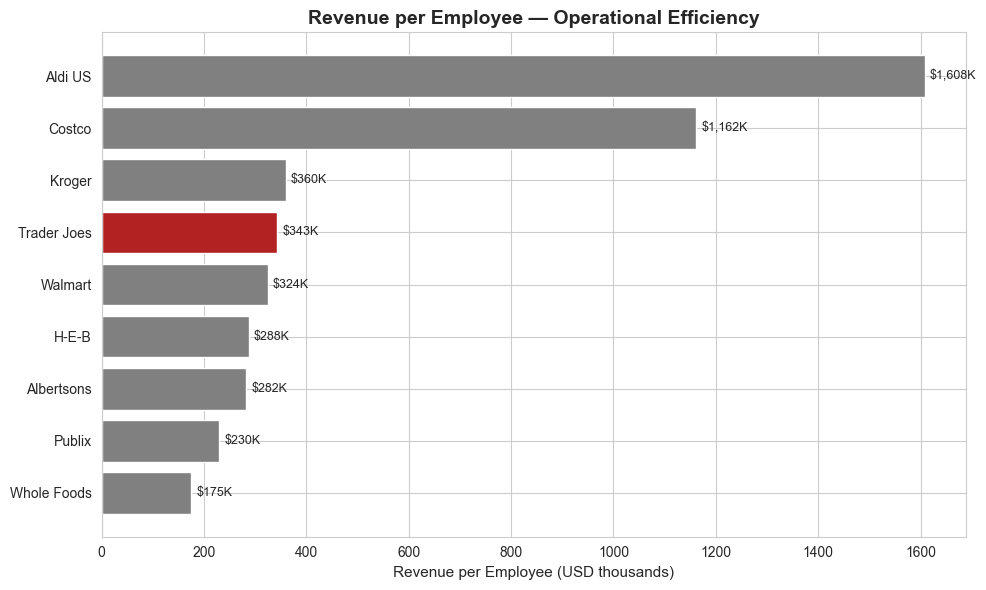

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
data = df.sort_values('revenue_per_employee_usd_k', ascending=True)

colors = ['#B22222' if c == 'Trader Joes' else '#808080' for c in data['chain']]

bars = ax.barh(data['chain'], data['revenue_per_employee_usd_k'], color=colors)

ax.set_xlabel('Revenue per Employee (USD thousands)', fontsize=11)
ax.set_title('Revenue per Employee — Operational Efficiency', fontsize=14, fontweight='bold')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 10, bar.get_y() + bar.get_height()/2,
            f'${width:,.0f}K', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../output/chart3_revenue_per_employee.png', dpi=150, bbox_inches='tight')
plt.show()

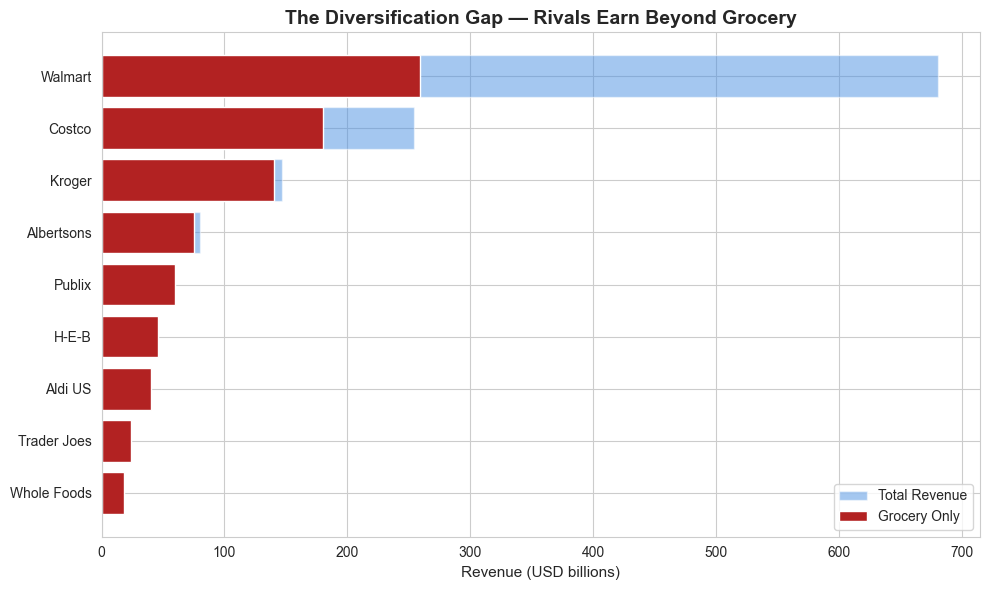

In [7]:
# Chart 4: Diversification gap — total revenue vs grocery-only
fig, ax = plt.subplots(figsize=(10, 6))

data = df.sort_values('revenue_usd_b', ascending=True)
x = range(len(data))

ax.barh(x, data['revenue_usd_b'], color='#4A90E2', alpha=0.5, label='Total Revenue')
ax.barh(x, data['grocery_revenue_usd_b'], color='#B22222', label='Grocery Only')

ax.set_yticks(x)
ax.set_yticklabels(data['chain'])
ax.set_xlabel('Revenue (USD billions)', fontsize=11)
ax.set_title('The Diversification Gap — Rivals Earn Beyond Grocery', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../output/chart4_diversification_gap.png', dpi=150, bbox_inches='tight')
plt.show()